# TalknShop Research Metrics Analysis Template

This notebook computes the core metrics proposed in the paper and generates paper-ready plots.

Expected input files (CSV):
- `documentation/metrics_template.csv` (task outcomes + SUS answers)
- Optional: `documentation/result_quality.csv` (for precision/recall)
- Optional: `documentation/latency_breakdown.csv` (for latency chart)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

ROOT = Path.cwd()
if (ROOT / 'documentation').exists():
    DOCS_DIR = ROOT / 'documentation'
else:
    DOCS_DIR = ROOT

METRICS_CSV = DOCS_DIR / 'metrics_template.csv'
RESULT_QUALITY_CSV = DOCS_DIR / 'result_quality.csv'
LATENCY_CSV = DOCS_DIR / 'latency_breakdown.csv'

print('Docs dir:', DOCS_DIR)
print('Metrics file exists:', METRICS_CSV.exists())

Docs dir: /Users/sameer/Documents/1-SJSU/masters-project/talknshop/documentation
Metrics file exists: True


In [2]:
df = pd.read_csv(METRICS_CSV)

for c in ['start_ts', 'end_ts']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce', utc=True)

# If task_time_sec is missing, compute from timestamps.
if 'task_time_sec' not in df.columns and {'start_ts', 'end_ts'}.issubset(df.columns):
    df['task_time_sec'] = (df['end_ts'] - df['start_ts']).dt.total_seconds()

df.head()

,participant_id,group,task_id,task_type,start_ts,end_ts,task_time_sec,completed,purchase_made,listing_posted_count,target_marketplaces_count,clarification_rounds,conversation_turns,relevance_score_human,sus_q1,sus_q2,sus_q3,sus_q4,sus_q5,sus_q6,sus_q7,sus_q8,sus_q9,sus_q10
0,P001,talknshop,T001,simple_search,2026-04-09 10:00:00+00:00,2026-04-09 10:01:10+00:00,70,1,0,0,0,1,6,8.5,4,4,5,2,4,2,5,2,4,2
1,P002,talknshop,T002,simple_search,2026-04-09 10:05:00+00:00,2026-04-09 10:06:18+00:00,78,1,0,0,0,1,7,8.2,4,4,5,2,4,2,5,2,4,2
2,P003,talknshop,T003,multi_criteria_search,2026-04-09 10:10:00+00:00,2026-04-09 10:12:05+00:00,125,1,0,0,0,2,9,8.8,5,4,5,2,4,2,5,2,4,1
3,P004,talknshop,T004,multi_criteria_search,2026-04-09 10:15:00+00:00,2026-04-09 10:17:20+00:00,140,1,0,0,0,2,10,8.4,4,4,5,2,4,2,5,2,4,2
4,P005,talknshop,T005,cross_marketplace_compare,2026-04-09 10:20:00+00:00,2026-04-09 10:23:05+00:00,185,1,1,0,0,2,11,9.1,4,4,5,2,4,2,5,2,4,2


## SUS Score Calculation

SUS scoring rule:
- Odd questions (1,3,5,7,9): score - 1
- Even questions (2,4,6,8,10): 5 - score
- Sum all adjusted values and multiply by 2.5

In [3]:
sus_cols = [f'sus_q{i}' for i in range(1, 11)]

if set(sus_cols).issubset(df.columns):
    odd_cols = [f'sus_q{i}' for i in [1, 3, 5, 7, 9]]
    even_cols = [f'sus_q{i}' for i in [2, 4, 6, 8, 10]]

    adjusted = pd.DataFrame(index=df.index)
    adjusted[odd_cols] = df[odd_cols].apply(pd.to_numeric, errors='coerce') - 1
    adjusted[even_cols] = 5 - df[even_cols].apply(pd.to_numeric, errors='coerce')
    df['sus_score'] = adjusted.sum(axis=1) * 2.5
else:
    df['sus_score'] = np.nan

df[['participant_id', 'group', 'sus_score']].dropna().drop_duplicates().head()

,participant_id,group,sus_score
0,P001,talknshop,75.0
1,P002,talknshop,75.0
2,P003,talknshop,80.0
3,P004,talknshop,75.0
4,P005,talknshop,75.0


## Core Metrics (Descriptive Stats)

In [4]:
summary_time = (
    df.groupby(['group', 'task_type'], dropna=False)['task_time_sec']
      .agg(['count', 'mean', 'median', 'std'])
      .reset_index()
)

summary_success = (
    df.groupby(['group', 'task_type'], dropna=False)['completed']
      .mean()
      .reset_index(name='success_rate')
)

summary_purchase = (
    df.groupby(['group', 'task_type'], dropna=False)['purchase_made']
      .mean()
      .reset_index(name='purchase_rate')
)

summary_turns = (
    df.groupby(['group', 'task_type'], dropna=False)['conversation_turns']
      .agg(['mean', 'median'])
      .reset_index()
)

display(summary_time)
display(summary_success)
display(summary_purchase)
display(summary_turns)

,group,task_type,count,mean,median,std
0,talknshop,cross_marketplace_compare,2,196.5,196.5,16.263456
1,talknshop,multi_criteria_search,2,132.5,132.5,10.606602
2,talknshop,multi_listing,2,585.0,585.0,49.497475
3,talknshop,simple_search,2,74.0,74.0,5.656854
4,talknshop,single_listing,2,305.0,305.0,21.213203
5,traditional,cross_marketplace_compare,2,435.0,435.0,49.497475
6,traditional,multi_criteria_search,2,287.5,287.5,31.819805
7,traditional,multi_listing,2,1305.0,1305.0,120.208153
8,traditional,simple_search,2,147.5,147.5,17.677670
9,traditional,single_listing,2,585.0,585.0,63.639610


,group,task_type,success_rate
0,talknshop,cross_marketplace_compare,1.0
1,talknshop,multi_criteria_search,1.0
2,talknshop,multi_listing,1.0
3,talknshop,simple_search,1.0
4,talknshop,single_listing,1.0
5,traditional,cross_marketplace_compare,1.0
6,traditional,multi_criteria_search,1.0
7,traditional,multi_listing,1.0
8,traditional,simple_search,1.0
9,traditional,single_listing,1.0


,group,task_type,purchase_rate
0,talknshop,cross_marketplace_compare,1.0
1,talknshop,multi_criteria_search,0.0
2,talknshop,multi_listing,0.0
3,talknshop,simple_search,0.0
4,talknshop,single_listing,0.0
5,traditional,cross_marketplace_compare,1.0
6,traditional,multi_criteria_search,0.0
7,traditional,multi_listing,0.0
8,traditional,simple_search,0.0
9,traditional,single_listing,0.0


,group,task_type,mean,median
0,talknshop,cross_marketplace_compare,11.5,11.5
1,talknshop,multi_criteria_search,9.5,9.5
2,talknshop,multi_listing,14.5,14.5
3,talknshop,simple_search,6.5,6.5
4,talknshop,single_listing,10.5,10.5
5,traditional,cross_marketplace_compare,0.0,0.0
6,traditional,multi_criteria_search,0.0,0.0
7,traditional,multi_listing,0.0,0.0
8,traditional,simple_search,0.0,0.0
9,traditional,single_listing,0.0,0.0


## Statistical Tests (TalknShop vs Traditional)

In [5]:
def compare_groups_continuous(data, metric):
    a = pd.to_numeric(data.loc[data['group'] == 'talknshop', metric], errors='coerce').dropna()
    b = pd.to_numeric(data.loc[data['group'] == 'traditional', metric], errors='coerce').dropna()
    if len(a) < 2 or len(b) < 2:
        return {'metric': metric, 'test': 'insufficient data'}

    # Welch's t-test (robust to unequal variances)
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)

    # Cohen's d
    pooled_sd = np.sqrt(((a.std(ddof=1) ** 2) + (b.std(ddof=1) ** 2)) / 2)
    d = (a.mean() - b.mean()) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) else np.nan

    return {
        'metric': metric,
        'talknshop_mean': a.mean(),
        'traditional_mean': b.mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'cohens_d': d,
    }

tests = [
    compare_groups_continuous(df, 'task_time_sec'),
    compare_groups_continuous(df, 'conversation_turns'),
    compare_groups_continuous(df, 'clarification_rounds'),
    compare_groups_continuous(df, 'sus_score'),
]

pd.DataFrame(tests)

/Users/sameer/Documents/1-SJSU/masters-project/talknshop/.venv-docx/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,metric,talknshop_mean,traditional_mean,t_stat,p_value,cohens_d
0,task_time_sec,258.6,552.0,-1.977419,7.058309e-02,-0.884329
1,conversation_turns,10.5,0.0,11.863586,8.486994e-07,5.305557
2,clarification_rounds,2.1,0.0,9.000000,8.538051e-06,4.024922
3,sus_score,76.0,55.0,31.500000,1.607062e-10,14.087228


## Paper Plot 1: Task Completion Time by Task Type

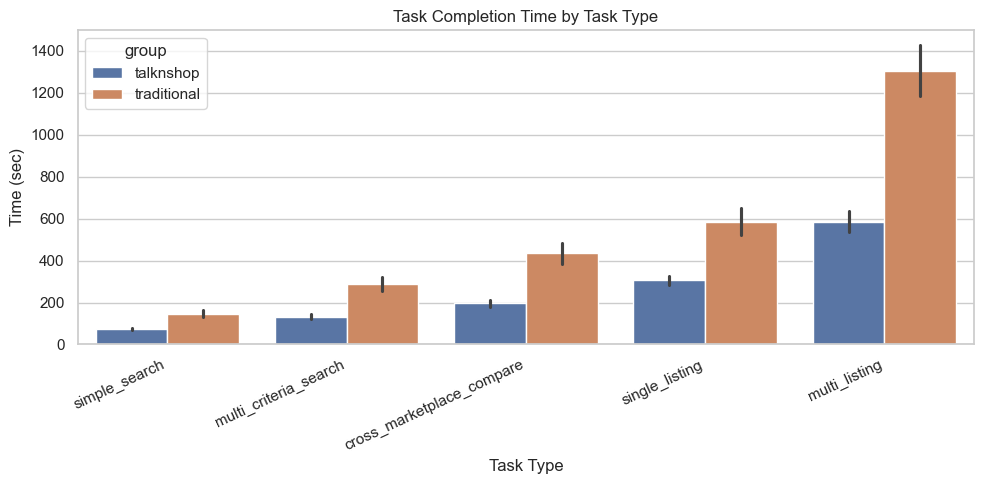

In [6]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df, x='task_type', y='task_time_sec', hue='group', errorbar='sd')
ax.set_title('Task Completion Time by Task Type')
ax.set_xlabel('Task Type')
ax.set_ylabel('Time (sec)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Paper Plot 2: SUS Distribution

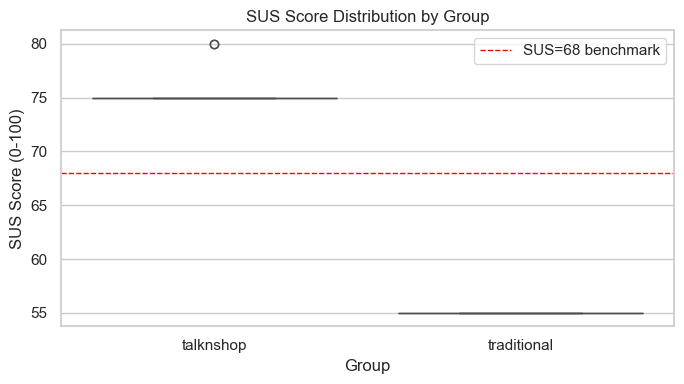

In [7]:
sus_df = df[['participant_id', 'group', 'sus_score']].dropna().drop_duplicates()

if not sus_df.empty:
    plt.figure(figsize=(7, 4))
    ax = sns.boxplot(data=sus_df, x='group', y='sus_score')
    ax.axhline(68, color='red', linestyle='--', linewidth=1, label='SUS=68 benchmark')
    ax.set_title('SUS Score Distribution by Group')
    ax.set_xlabel('Group')
    ax.set_ylabel('SUS Score (0-100)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No SUS data available.')

## Optional: Precision@k and Recall@k

Expected `result_quality.csv` columns:
- `task_id`, `returned_rank`, `is_relevant`
- Optional grouping columns: `group`, `product_category`

In [8]:
def precision_recall_at_k(dfq, k=5):
    topk = dfq.nsmallest(k, 'returned_rank')
    rel_topk = topk['is_relevant'].sum()
    total_rel = dfq['is_relevant'].sum()
    precision = rel_topk / k if k > 0 else np.nan
    recall = rel_topk / total_rel if total_rel > 0 else np.nan
    return precision, recall

if RESULT_QUALITY_CSV.exists():
    rq = pd.read_csv(RESULT_QUALITY_CSV)
    rq['returned_rank'] = pd.to_numeric(rq['returned_rank'], errors='coerce')
    rq['is_relevant'] = pd.to_numeric(rq['is_relevant'], errors='coerce').fillna(0)

    rows = []
    for task_id, grp in rq.groupby('task_id'):
        p5, r5 = precision_recall_at_k(grp, k=5)
        rows.append({'task_id': task_id, 'precision_at_5': p5, 'recall_at_5': r5})

    pr = pd.DataFrame(rows)
    display(pr.head())
    print('Mean Precision@5:', pr['precision_at_5'].mean())
    print('Mean Recall@5:', pr['recall_at_5'].mean())
else:
    print('Optional file not found:', RESULT_QUALITY_CSV)

,task_id,precision_at_5,recall_at_5
0,T001,0.6,1.0
1,T002,0.6,1.0
2,T003,0.6,1.0
3,T005,0.6,1.0
4,T014,0.6,1.0


Mean Precision@5: 0.6
Mean Recall@5: 1.0


## Optional: Latency Breakdown Plot

Expected `latency_breakdown.csv` columns:
- `group`, `task_type`, `ws_ms`, `llm_ms`, `api_ms`, `ranking_ms`, `total_ms`

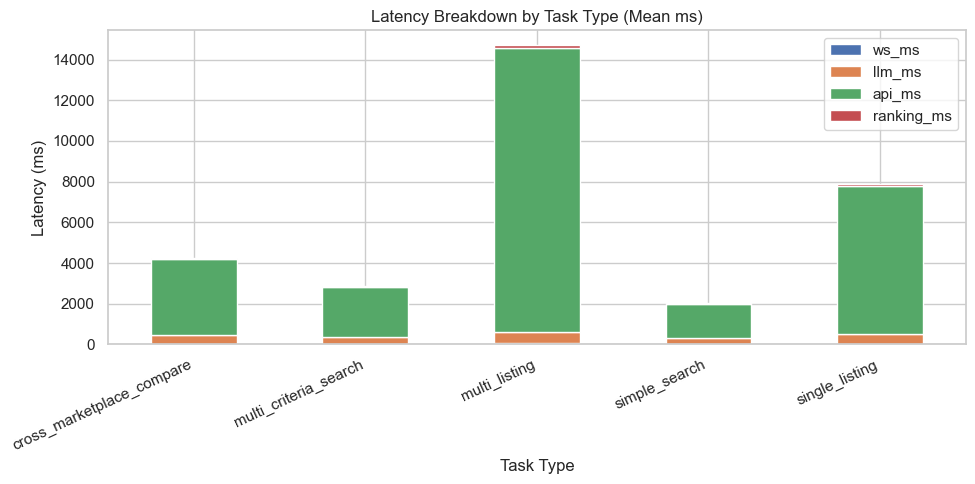

In [9]:
if LATENCY_CSV.exists():
    lat = pd.read_csv(LATENCY_CSV)
    comp_cols = ['ws_ms', 'llm_ms', 'api_ms', 'ranking_ms']
    lat_grouped = lat.groupby('task_type', dropna=False)[comp_cols].mean().reset_index()

    lat_grouped = lat_grouped.set_index('task_type')
    lat_grouped.plot(kind='bar', stacked=True, figsize=(10, 5))
    plt.title('Latency Breakdown by Task Type (Mean ms)')
    plt.xlabel('Task Type')
    plt.ylabel('Latency (ms)')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Optional file not found:', LATENCY_CSV)

## Next Steps

1. Replace sample rows in `metrics_template.csv` with real study data.
2. Add `result_quality.csv` and `latency_breakdown.csv` when available.
3. Export summary tables and figures for your paper.
4. Report p-values, effect sizes, and confidence intervals in the Results section.